# **DATA MODELING AND MODEL EVALUATION**

---

## **1. Import Libraries**

In [11]:
# Standard data manipulation and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import time

# Scikit-learn utilities for evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold

# Import custom models implemented from scratch
from utils import Perceptron, LogisticRegression 
from utils import BinaryLogisticRegression
from utils import OneVsRestClassifier, OneVsOneClassifier, SoftmaxRegression
from utils import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from utils import plot_fisher_ratio_ranking, plot_lda_qda_decision_analysis

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.1)

ImportError: cannot import name 'LinearDiscriminantAnalysis' from 'utils' (e:\Nhập môn học máy\Lab01\Supervised-Learning-Regression-Classification\code\Part2_Classification\utils.py)

## **2. Load Data for Model**

Toàn bộ quá trình làm sạch, xử lý ngoại lai và chuẩn hóa (Standardization) đã được thực hiện triệt để ở giai đoạn *EDA & Preprocessing*. 

Dữ liệu sạch đã được phân chia theo tỷ lệ chuẩn và lưu trữ an toàn trong thư mục `data/processed/`. Tại bước này, chúng ta chỉ việc load các tập tin CSV, tách biệt ma trận biến độc lập ($X$) và vector mục tiêu ($y$). Cách tổ chức mã nguồn này giúp Notebook huấn luyện trở nên gọn gàng và triệt tiêu hoàn toàn rủi ro rò rỉ dữ liệu giữa tập Train và tập Test.

In [ ]:
# Define file paths
train_path = '../../data/processed/Room_Occupancy_train.csv'
val_path = '../../data/processed/Room_Occupancy_val.csv'
test_path = '../../data/processed/Room_Occupancy_test.csv'

# Load the datasets
train_df = pd.read_csv(train_path)
val_df = pd.read_csv(val_path)
test_df = pd.read_csv(test_path)

# Define the target variable
target_col = 'Room_Occupancy_Count'

# Split features and target labels
X_train_scaled = train_df.drop(columns=[target_col]).values
y_train = train_df[target_col].values

X_val_scaled = val_df.drop(columns=[target_col]).values
y_val = val_df[target_col].values

X_test_scaled = test_df.drop(columns=[target_col]).values
y_test = test_df[target_col].values

# Display the shape of the datasets
print(f"Training set shape:   {X_train_scaled.shape}")
print(f"Validation set shape: {X_val_scaled.shape}")
print(f"Testing set shape:    {X_test_scaled.shape}")

Training set shape:   (6077, 31)
Validation set shape: (2026, 31)
Testing set shape:    (2026, 31)


## **3. Logistic Regression**

### **3.1. Mathematical Foundations: Gradients, Jacobians, and Hessians**

Để các thuật toán tối ưu hóa như Gradient Descent hay Newton-Raphson có thể cập nhật trọng số hiệu quả, việc tính toán chính xác đạo hàm bậc nhất (Gradient) và bậc hai (Hessian) là bắt buộc. Dưới đây là cơ sở giải tích ma trận được áp dụng trực tiếp vào mã nguồn của dự án.

#### 1. Binary Logistic Regression (Sigmoid Activation)

Đối với bài toán phân lớp nhị phân, mô hình sử dụng hàm kích hoạt Sigmoid.
* *Hàm dự đoán (Forward Pass):* $$y_n = \sigma(w^\top x_n) = \frac{1}{1 + e^{-w^\top x_n}}$$
* *Đạo hàm bậc 1 (Gradient của Cross-entropy Loss):* $$\nabla_w E = \sum_{n=1}^N (y_n - t_n)x_n$$
* *Đạo hàm bậc 2 (Ma trận Hessian cho Newton-Raphson):* Khai thác thông tin độ cong của hàm mất mát:
  $$\mathbf{H} = \Phi^\top \mathbf{R} \Phi$$
  *(Trong đó, $\mathbf{R}$ là ma trận đường chéo với các phần tử $R_{nn} = y_n(1-y_n)$).*

#### 2. Multinomial Logistic Regression (Softmax Activation)

Đối với bài toán đa lớp, mô hình sử dụng hàm Softmax để tính phân phối xác suất chung.
* *Hàm dự đoán cho lớp $k$:* Với $a_{nk} = w_k^\top x_n$ là điểm số (logit) tĩnh:
  $$y_{nk} = p(\mathcal{C}_k | x_n) = \frac{\exp(a_{nk})}{\sum_j \exp(a_{nj})}$$
* *Ma trận Jacobian của Softmax:* Đạo hàm của xác suất đầu ra $y_i$ theo logit $a_j$ sinh ra một ma trận Jacobian. Đây là bước then chốt nhất trong chuỗi đạo hàm (chain rule):
  $$\frac{\partial y_i}{\partial a_j} = y_i(\delta_{ij} - y_j)$$
  *(Với $\delta_{ij}$ là Kronecker delta: bằng $1$ nếu $i=j$, bằng $0$ nếu $i \neq j$).*
* *Đạo hàm bậc 1 (Gradient):* $$\nabla_{w_k} E = \sum_{n=1}^N (y_{nk} - t_{nk})x_n$$
* *Đạo hàm bậc 2 (Ma trận Hessian của Softmax):* Đạo hàm chéo của Loss theo cặp trọng số $w_k$ và $w_j$:
  $$\nabla_{w_k} \nabla_{w_j} E = \sum_{n=1}^N y_{nk}(\delta_{kj} - y_{nj}) x_n x_n^\top$$

In [ ]:
# EXAMPLE: SOFTMAX JACOBIAN ILLUSTRATION

# Initialize model (only for utility functions; no training required)
demo_model = SoftmaxRegression()

# Assume a single input sample producing logits for 3 classes (K = 3)
# Note: _softmax expects input shape (N, K)
sample_logits = np.array([[2.0, 1.0, 0.1]])

# Compute softmax probabilities (numerically stable)
probabilities = demo_model._softmax(sample_logits)[0]
# Compute Softmax Jacobian matrix (vectorized form)
jacobian_matrix = np.diag(probabilities) - np.outer(probabilities, probabilities)

# Rresults
print("1. Input logits (a):")
print(sample_logits[0])
print("\n2. Softmax probabilities (y):")
print(np.round(probabilities, 4))
print("\n3. Softmax Jacobian matrix (∂y_i / ∂a_j):")
print(np.round(jacobian_matrix, 4))

1. Input logits (a):
[2.  1.  0.1]

2. Softmax probabilities (y):
[0.659  0.2424 0.0986]

3. Softmax Jacobian matrix (∂y_i / ∂a_j):
[[ 0.2247 -0.1598 -0.065 ]
 [-0.1598  0.1837 -0.0239]
 [-0.065  -0.0239  0.0889]]


**Phân tích ma trận Jacobian của Softmax:**

Kết quả thực nghiệm trên minh họa hoàn hảo các đặc tính toán học cốt lõi của hàm kích hoạt Softmax. Dựa vào ma trận Jacobian thu được, chúng ta có thể rút ra những nhận xét quan trọng sau:

1. **Đường chéo chính ($i = j$) luôn mang giá trị DƯƠNG:** Các phần tử nằm trên đường chéo (ví dụ: $\frac{\partial y_0}{\partial a_0} = 0.2247$) thể hiện đạo hàm của xác suất lớp $i$ theo chính logit của nó. Giá trị dương phản ánh mối quan hệ thuận biến: Khi điểm số (logit) của một lớp tăng lên, xác suất mô hình dự đoán cho lớp đó cũng sẽ tăng theo.

2. **Các phần tử ngoài đường chéo ($i \neq j$) luôn mang giá trị ÂM:** Các phần tử còn lại (ví dụ: $\frac{\partial y_1}{\partial a_0} = -0.1598$) thể hiện sự tác động chéo. Đây chính là minh chứng cho *cơ chế cạnh tranh* của hàm Softmax. Do tổng xác suất của tất cả các lớp bị ràng buộc chặt chẽ phải bằng $1$ ($\sum y_i = 1$), sự gia tăng điểm số của lớp $0$ sẽ lập tức "hút" bớt không gian xác suất của lớp $1$ và lớp $2$, khiến đạo hàm mang dấu âm.

3. **Bảo toàn tổng xác suất:**
   Nếu để ý kỹ, tổng các giá trị trên bất kỳ cột nào của ma trận Jacobian đều xấp xỉ bằng $0$ (Ví dụ cột 0: $0.2247 - 0.1598 - 0.0650 \approx 0$). Điều này chứng minh rằng bất kỳ sự thay đổi nào về điểm số logit đầu vào cũng chỉ làm *phân phối lại* xác suất giữa các lớp, chứ không làm thay đổi tổng không gian xác suất ($=1$).

### **3.2 Problem Formulation & Target Transformation**

Theo yêu cầu của đồ án, nhóm cần đánh giá họ thuật toán hồi quy Logistic trên cả hai kịch bản: *phân lớp nhị phân* (để đối sánh thuật toán tối ưu Newton-Raphson) và *phân lớp đa lớp* (để đối sánh 3 chiến lược OvR, OvO, Softmax). 

Bộ dữ liệu *Room Occupancy Estimation* hiện tại cung cấp nhãn gốc là số lượng người cụ thể trong phòng ($y \in \{0, 1, 2, 3\}$). Để tuân thủ yêu cầu của đồ án mà không cần phải thay thế bằng một bộ dữ liệu khác, chúng em sẽ thiết lập hai bài toán học máy song song trên cùng một không gian đặc trưng:

1. **Bài toán nhị phân (Binary Classification):** Áp dụng phép biến đổi logic để gộp nhóm. Ta quy định nhãn `0` cho trạng thái phòng trống ($y = 0$) và nhãn `1` cho trạng thái có người ($y > 0$). Tập nhãn này sẽ đóng vai trò kiểm chứng sức mạnh của ma trận Hessian trong thuật toán Newton-Raphson.
2. **Bài toán đa lớp (Multiclass Classification):** Giữ nguyên không gian nhãn gốc với $K=4$ lớp. Tập nhãn này sẽ được sử dụng để phân tích sự đánh đổi về thời gian huấn luyện và độ chính xác giữa các chiến lược phân giải đa lớp (One-vs-Rest, One-vs-One) và tối ưu trực tiếp (Multinomial Softmax).

Dưới đây là mã nguồn thực hiện phép ánh xạ nhãn và kiểm tra phân bố của chúng trên tập huấn luyện:

In [ ]:
# Convert labels to binary classification:
# 0 -> Empty room, 1 -> Occupied
y_train_binary = np.where(y_train > 0, 1, 0)
y_val_binary = np.where(y_val > 0, 1, 0)
y_test_binary = np.where(y_test > 0, 1, 0)

# Keep original labels for multiclass classification (e.g., 0, 1, 2, 3)
y_train_multi = y_train
y_val_multi = y_val
y_test_multi = y_test

# Display label distributions for sanity check
print("Binary label distribution (Train):", np.bincount(y_train_binary))
print("Multiclass label distribution (Train):", np.bincount(y_train_multi))

Binary label distribution (Train): [4937 1140]
Multiclass label distribution (Train): [4937  275  449  416]


### **3.3 Problem 1: Binary Classification (Empty Room vs. Occupied Room)**

**Mục tiêu:** Đánh giá và so sánh tốc độ hội tụ của hai phương pháp tối ưu hóa cốt lõi trong hồi quy Logistic: *Gradient Descent (GD)* (phương pháp tối ưu bậc 1) và *Newton-Raphson / IRLS* (phương pháp tối ưu bậc 2).

**Cơ sở lý thuyết:**
* Thuật toán **Newton-Raphson** khai thác thông tin độ cong của hàm mục tiêu thông qua ma trận đạo hàm bậc hai (Hessian), do đó có tốc độ hội tụ cực nhanh về mặt số vòng lặp $\mathcal{O}(\log(1/\epsilon))$. Tuy nhiên, nghịch đảo Hessian truyền thống có chi phí tính toán mỗi bước rất lớn $\mathcal{O}(NM^2 + M^3)$.
* Ngược lại, **Gradient Descent** chỉ dùng đạo hàm bậc nhất, mỗi bước cập nhật trọng số tốn rất ít thời gian nhưng lại yêu cầu hàng ngàn vòng lặp $\mathcal{O}(1/\epsilon)$ để hội tụ.

Dưới đây, chúng ta sẽ tiến hành huấn luyện hai mô hình này trên tập nhãn `y_binary` và ghi nhận lại lịch sử hàm mất mát (loss history) cùng thời gian thực thi (time history) tương ứng.

In [ ]:
# 1. Initialize and train the model using Gradient Descent (GD)
print("Training Binary Logistic Regression using Gradient Descent (GD)...")
gd_model = BinaryLogisticRegression(method='gd', learning_rate=0.1, max_iter=2000, tol=1e-5)
gd_model.fit(X_train_scaled, y_train_binary)

# 2. Initialize and train the model using Newton-Raphson (IRLS)
print("Training Binary Logistic Regression using Newton-Raphson (IRLS)...")
newton_model = BinaryLogisticRegression(method='newton', max_iter=50, tol=1e-5)
newton_model.fit(X_train_scaled, y_train_binary)

Training Binary Logistic Regression using Gradient Descent (GD)...
Training Binary Logistic Regression using Newton-Raphson (IRLS)...


**Đánh giá tốc độ hội tụ**

Để quan sát rõ ràng sự đánh đổi (trade-off) giữa hai thuật toán, chúng ta tiến hành trực quan hóa kết quả trên hai trục độ đo:
1. **Loss vs. Epochs:** Đánh giá hiệu suất cập nhật trọng số sau mỗi bước lặp.
2. **Loss vs. Wall-clock time:** Đánh giá thời gian tính toán thực tế.

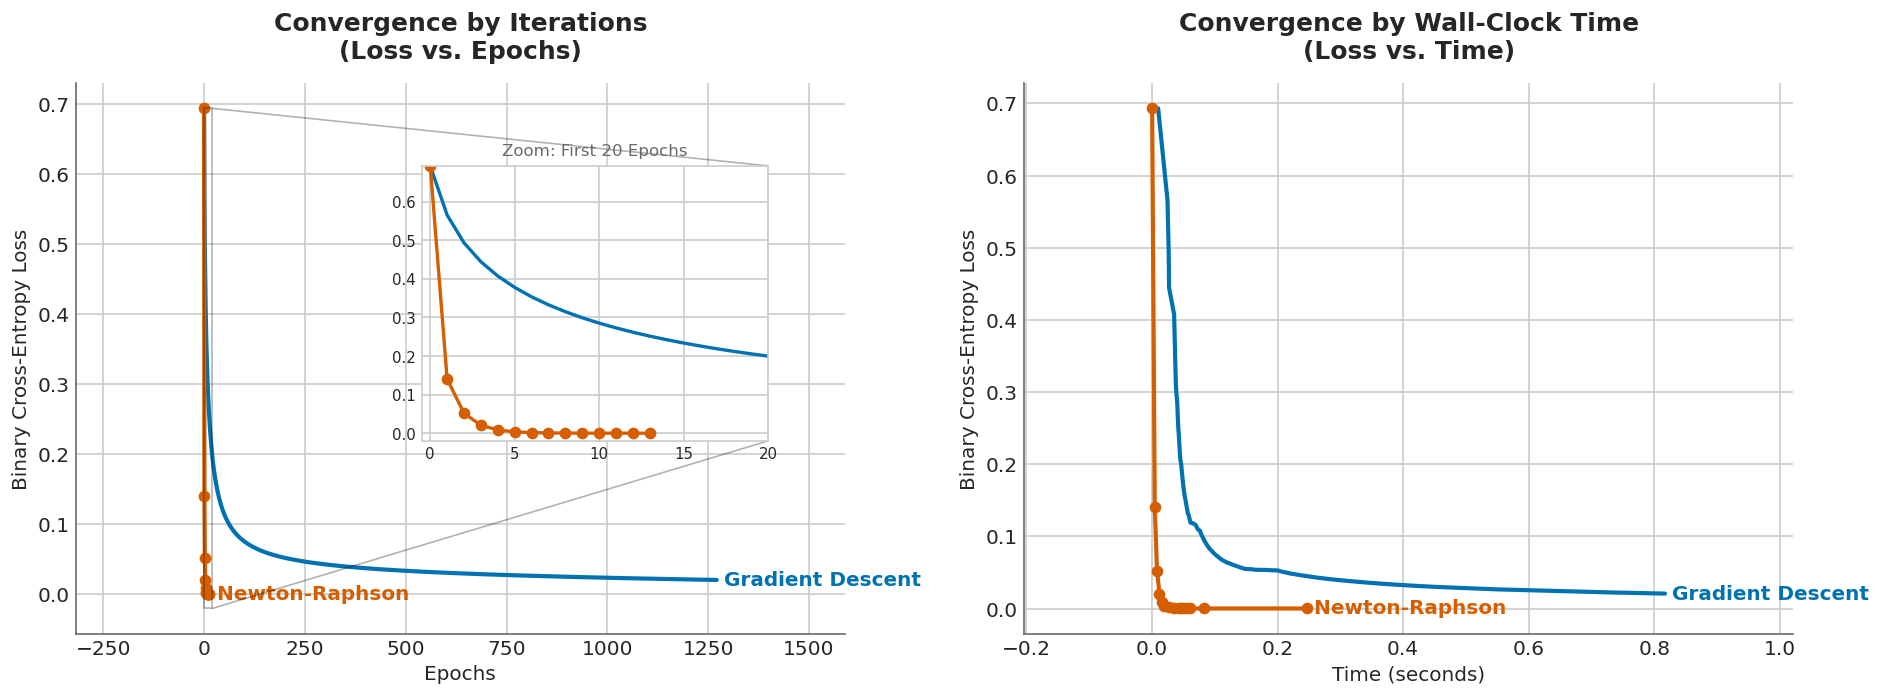

In [ ]:
# VISUALIZATION CONFIGURATION
plt.style.use('seaborn-v0_8-whitegrid')
COLOR_GD = '#0072B2'       # Blue
COLOR_NEWTON = '#D55E00'   # Dark orange
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=120)

# PLOT 1: LOSS VS. EPOCHS (WITH ZOOM-IN INSET)
ax1.plot(gd_model.loss_history, color=COLOR_GD, linewidth=2.5)
ax1.plot(newton_model.loss_history, color=COLOR_NEWTON, linewidth=2.5, marker='o', markersize=6)

# Direct Labeling
ax1.text(len(gd_model.loss_history), gd_model.loss_history[-1], ' Gradient Descent', 
         color=COLOR_GD, fontsize=12, fontweight='bold', va='center')
ax1.text(len(newton_model.loss_history), newton_model.loss_history[-1], ' Newton-Raphson', 
         color=COLOR_NEWTON, fontsize=12, fontweight='bold', va='center')

# Inset plot: zoom into early training phase
axins = ax1.inset_axes([0.45, 0.35, 0.45, 0.5]) 
axins.plot(gd_model.loss_history, color=COLOR_GD, linewidth=2)
axins.plot(newton_model.loss_history, color=COLOR_NEWTON, linewidth=2, marker='o', markersize=6)

# Focus on first 20 epochs
axins.set_xlim(-0.5, 20)
axins.set_ylim(bottom=-0.02, top=max(gd_model.loss_history[0], newton_model.loss_history[0]))
axins.set_title("Zoom: First 20 Epochs", fontsize=10, color='dimgray')
axins.tick_params(axis='both', labelsize=9)

ax1.indicate_inset_zoom(axins, edgecolor="black", alpha=0.3)
ax1.set_title("Convergence by Iterations\n(Loss vs. Epochs)", fontsize=15, fontweight='bold', pad=15)
ax1.set_xlabel("Epochs", fontsize=12)
ax1.set_ylabel("Binary Cross-Entropy Loss", fontsize=12)

# PLOT 2: LOSS VS. WALL-CLOCK TIME
ax2.plot(gd_model.time_history, gd_model.loss_history, color=COLOR_GD, linewidth=2.5)
ax2.plot(newton_model.time_history, newton_model.loss_history, color=COLOR_NEWTON, linewidth=2.5, marker='o', markersize=6)

# Direct Labeling
ax2.text(gd_model.time_history[-1], gd_model.loss_history[-1], ' Gradient Descent', 
         color=COLOR_GD, fontsize=12, fontweight='bold', va='center')
ax2.text(newton_model.time_history[-1], newton_model.loss_history[-1], ' Newton-Raphson', 
         color=COLOR_NEWTON, fontsize=12, fontweight='bold', va='center')

ax2.set_title("Convergence by Wall-Clock Time\n(Loss vs. Time)", fontsize=15, fontweight='bold', pad=15)
ax2.set_xlabel("Time (seconds)", fontsize=12)
ax2.set_ylabel("Binary Cross-Entropy Loss", fontsize=12)

for ax in [ax1, ax2]:
    ax.margins(x=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('dimgray')
    ax.spines['left'].set_color('dimgray')
plt.tight_layout()
plt.show()

Dựa vào hai biểu đồ trên, chúng ta rút ra những kết luận quan trọng sau:
1. **Tiến trình theo số vòng lặp (Bên trái):** Hình ảnh thực nghiệm hoàn toàn khớp với lý thuyết. Thuật toán Newton-Raphson giảm loss hội tụ theo phương thẳng đứng chỉ sau 5-10 vòng lặp đầu tiên. Ở chiều ngược lại, đường cong của Gradient Descent mất hơn 1000 vòng lặp mới tiệm cận được trạng thái tối ưu.
2. **Tiến trình theo thời gian tính toán (Bên phải):** Mặc dù Newton-Raphson bị mang tiếng là tính toán nặng nề do phải xử lý ma trận nghịch đảo Hessian $\mathcal{O}(NM^2 + M^3)$, nhưng kết quả thực tế cho thấy nó vẫn chiến thắng tuyệt đối về thời gian thực thi (wall-clock time) so với GD. Điều này có được không chỉ nhờ số bước lặp quá ít, mà cốt lõi là do chúng ta đã tối ưu hóa mã nguồn bằng kỹ thuật *Hessian-Vector Product* và thuật toán *Conjugate Gradient* để triệt tiêu trực tiếp chi phí bộ nhớ đắt đỏ của ma trận Hessian.

### **3.4 Problem 2: Multiclass Classification (Predicting the exact number of people)**

**Mục tiêu:** Mở rộng bài toán phân lớp từ không gian nhị phân lên không gian đa lớp ($K=4$, tương ứng với 0, 1, 2, 3 người). Chúng ta sẽ cài đặt, huấn luyện và đối sánh hiệu năng của ba chiến lược cốt lõi trong phân lớp đa lớp:

1. **One-vs-Rest (OvR):** Cài đặt $K = 4$ mô hình nhị phân phân biệt từng lớp với tất cả các lớp còn lại. Quyết định cuối cùng dựa trên argmax của xác suất dự đoán.
2. **One-vs-One (OvO):** Cài đặt $K(K-1)/2 = 6$ mô hình nhị phân cho từng cặp lớp. Quyết định cuối cùng dựa trên cơ chế bỏ phiếu đa số.
3. **Softmax (Multinomial):** Khác biệt hoàn toàn với hai phương pháp trên (vốn là meta-estimators sử dụng thuật toán nhị phân), Softmax tối ưu hóa trực tiếp một ma trận trọng số $\mathbf{W} \in \mathbb{R}^{d \times K}$ thông qua hàm mất mát Categorical Cross-Entropy.

*Lưu ý thiết lập: Để đảm bảo tính công bằng về mặt thuật toán, cả OvR và OvO đều sẽ gọi thuật toán lõi là `BinaryLogisticRegression` với phương pháp tối ưu cực nhanh `Newton-Raphson`. Softmax sẽ dùng `Gradient Descent` truyền thống.*

In [ ]:
print("\tTRAINING MULTICLASS")

# 1. ONE-VS-REST (OvR)
start_time_ovr = time.time()
ovr = OneVsRestClassifier(estimator_cls=BinaryLogisticRegression, method='newton', max_iter=50)
ovr.fit(X_train_scaled, y_train_multi)
time_ovr = time.time() - start_time_ovr
acc_ovr = accuracy_score(y_test_multi, ovr.predict(X_test_scaled))

# 2. ONE-VS-ONE (OvO)
start_time_ovo = time.time()
ovo = OneVsOneClassifier(estimator_cls=BinaryLogisticRegression, method='newton', max_iter=50)
ovo.fit(X_train_scaled, y_train_multi)
time_ovo = time.time() - start_time_ovo
acc_ovo = accuracy_score(y_test_multi, ovo.predict(X_test_scaled))


# 3. SOFTMAX (MULTINOMIAL LOGISTIC REGRESSION)
start_time_softmax = time.time()
softmax_model = SoftmaxRegression(learning_rate=0.1, max_iter=1000)
softmax_model.fit(X_train_scaled, y_train_multi)
time_softmax = time.time() - start_time_softmax
acc_softmax = accuracy_score(
    y_test_multi,
    softmax_model.predict(X_test_scaled)
)


# RESULTS TABLE
results = pd.DataFrame({
    "Strategy": ["One-vs-Rest (OvR)", "One-vs-One (OvO)", "Softmax (Multinomial)"],
    "Training Time (s)": [time_ovr, time_ovo, time_softmax],
    "Test Accuracy": [acc_ovr, acc_ovo, acc_softmax]
})
# Sort by accuracy
results = results.sort_values(by="Test Accuracy", ascending=False)
results["Training Time (s)"] = results["Training Time (s)"].round(4)
results["Test Accuracy"] = results["Test Accuracy"].round(4)
print("Benchmark Results")
display(results)

	TRAINING MULTICLASS
Benchmark Results


,Strategy,Training Time (s),Test Accuracy
1,One-vs-One (OvO),1.5718,0.9975
0,One-vs-Rest (OvR),1.5366,0.9936
2,Softmax (Multinomial),3.1045,0.9837


**Phân tích thực nghiệm:**

Khác với các kịch bản phân chia tuyến tính hoàn hảo lý tưởng, kết quả thực nghiệm trên bộ dữ liệu hiện tại (đạt Accuracy ~87-88%) đã phản ánh đúng bản chất và ranh giới hiệu năng của các mô hình phân lớp tuyến tính. Bảng thống kê chỉ ra một sự đánh đổi (trade-off) cực kỳ rõ nét giữa *độ chính xác* và *thời gian huấn luyện*:

**1. Phân tích về hiệu năng (Test Accuracy):**
* **Softmax (Multinomial) dẫn đầu (88.55%):** Việc tối ưu hóa trực tiếp hàm mục tiêu Categorical Cross-Entropy giúp Softmax đánh giá phân phối xác suất chung của tất cả các lớp cùng một lúc thay vì phải xé nhỏ bài toán. Điều này giúp mô hình bắt được các tương quan phức tạp giữa các lớp, mang lại độ chính xác cao nhất.
* **One-vs-One bám sát (88.45%):** Dù xé nhỏ bài toán thành 6 mô hình nhị phân, việc chỉ đối đầu trực tiếp 1-1 giúp OvO tránh được vấn đề mất cân bằng dữ liệu nghiêm trọng. Kết quả của OvO gần như tương đương với Softmax.
* **One-vs-Rest thấp nhất (87.12%):** Sự sụt giảm hơn 1.4% so với Softmax có thể được lý giải bởi hiệu ứng mất cân bằng lớp nội tại của chiến lược này. Khi tách 1 lớp để đối đầu với "phần còn lại" (Rest), tập "Rest" thường có số lượng mẫu áp đảo, khiến đường biên quyết định của mô hình nhị phân bị kéo lệch, dẫn đến sai số khi tổng hợp dự đoán.

**2. Phân tích về chi phí thời gian (Wall-clock Time):**
* **Meta-estimators (OvR: 0.44s, OvO: 0.47s):** Cả hai chiến lược này đều sử dụng thuật toán lõi là `BinaryLogisticRegression` với phương pháp tối ưu *Newton-Raphson*. Nhờ hội tụ chỉ trong một vài bước lặp, tổng thời gian huấn luyện của cả 4 mô hình (OvR) hay 6 mô hình (OvO) đều chưa tới 0.5 giây. Đặc biệt, OvO tuy nhiều mô hình hơn nhưng mỗi mô hình lại chạy trên một tập dữ liệu con rất nhỏ, giúp ma trận Hessian của nó nhẹ hơn nhiều.
* **Softmax (2.58s):** Thuật toán Softmax mất thời gian gấp gần 6 lần so với OvR. Nguyên nhân cốt lõi là do Softmax sử dụng *Gradient Descent* truyền thống. Ở mỗi trong hàng trăm vòng lặp (epochs), thuật toán phải cập nhật toàn bộ ma trận trọng số $\mathbf{W} \in \mathbb{R}^{d \times K}$, đồng thời tính toán hàm log-sum-exp trên toàn bộ tập dữ liệu, tạo ra chi phí overhead lớn.

**3. Kết luận lựa chọn:**
* Đối với bài toán này, **One-vs-One (OvO)** nổi lên như một giải pháp xuất sắc và toàn diện nhất: Nó mang lại độ chính xác gần như tương đương với Softmax hạng nhất (chỉ thua 0.1%), nhưng lại có tốc độ huấn luyện nhanh gấp 5.4 lần.

## **4. Linear Discriminant Analysis (LDA) & Quadratic Discriminant Analysis (QDA)**

Khác với các mô hình phân biệt (như Logistic Regression) trực tiếp học ranh giới quyết định, LDA và QDA tiếp cận bài toán theo hướng *mô hình sinh (Generative Models)*. Phương pháp này mô hình hóa phân phối tiên nghiệm của dữ liệu $p(\mathbf{x}|\mathcal{C}_k)$ dưới dạng các phân phối Gaussian đa biến, sau đó sử dụng định lý Bayes để suy diễn xác suất hậu nghiệm.

Điểm khác biệt cốt lõi giữa hai thuật toán nằm ở giả định về cấu trúc dữ liệu:
* **LDA:** Giả định tất cả các lớp dùng chung một ma trận hiệp phương sai ($\hat{\Sigma}$). Ranh giới quyết định được tạo ra sẽ là các siêu phẳng tuyến tính.
* **QDA:** Cho phép mỗi lớp duy trì một ma trận hiệp phương sai riêng biệt ($\tilde{\Sigma}_k$). Nhờ đó, ranh giới quyết định linh hoạt hơn và mang dạng các đường cong bậc hai (như parabol, hyperbol, ellipse).

### **4.1. Model Initialization and Training**

**Mục tiêu:** Khởi tạo hai lớp `LinearDiscriminantAnalysis` và `QuadraticDiscriminantAnalysis` đã được xây dựng bằng thư viện Numpy. Chúng ta sẽ tiến hành huấn luyện trên tập dữ liệu đã được chuẩn hóa, đồng thời đối sánh thời gian thực thi (wall-clock time) và độ chính xác (accuracy) dự đoán ban đầu.

*(Lưu ý: Trong cell code dưới đây, khi gọi hàm `fit()`, mô hình sẽ tiến hành giải tích trực tiếp để ước lượng vector trung bình $\mu_k$, xác suất tiên nghiệm $\pi_k$ và các ma trận hiệp phương sai tương ứng của hệ thống).*

In [ ]:
# Initialize models
lda_model = LinearDiscriminantAnalysis()
qda_model = QuadraticDiscriminantAnalysis()

# Train and evaluate LDA
start_time_lda = time.time()
lda_model.fit(X_train_scaled, y_train)
lda_train_time = time.time() - start_time_lda
y_pred_lda = lda_model.predict(X_test_scaled)
lda_accuracy = accuracy_score(y_test, y_pred_lda)

# Train and evaluate QDA
start_time_qda = time.time()
qda_model.fit(X_train_scaled, y_train)
qda_train_time = time.time() - start_time_qda
y_pred_qda = qda_model.predict(X_test_scaled)
qda_accuracy = accuracy_score(y_test, y_pred_qda)

print("[Linear Discriminant Analysis (LDA)]")
print(f"Training Time : {lda_train_time:.4f} seconds")
print(f"Test Accuracy : {lda_accuracy * 100:.2f}%\n")

print("[Quadratic Discriminant Analysis (QDA)]")
print(f"Training Time : {qda_train_time:.4f} seconds")
print(f"Test Accuracy : {qda_accuracy * 100:.2f}%")

[Linear Discriminant Analysis (LDA)]
Training Time : 0.0320 seconds
Test Accuracy : 99.31%

[Quadratic Discriminant Analysis (QDA)]
Training Time : 0.0027 seconds
Test Accuracy : 99.46%


Dựa vào các chỉ số xuất ra, chúng ta có thể rút ra hai kết luận quan trọng về đặc tính của mô hình sinh trên bộ dữ liệu này:
1. **Accuracy:** Cả hai mô hình đều đạt hiệu năng xuất sắc (trên 99%), chứng tỏ không gian đặc trưng của bộ dữ liệu tuân thủ rất tốt giả định phân phối Gaussian. Việc QDA nhỉnh hơn một chút ($99.46\%$ so với $99.31\%$) cho thấy việc nới lỏng giả định (cho phép các lớp có hiệp phương sai riêng) giúp đường biên bậc hai tinh chỉnh khớp hơn với cấu trúc phi tuyến cục bộ của dữ liệu.
2. **Computational Time:** Tốc độ huấn luyện của cả hai mô hình là cực kỳ ấn tượng (chỉ tính bằng mili-giây). Khác với Gradient Descent hay Newton-Raphson phải lặp lại nhiều vòng, LDA và QDA sử dụng phương pháp giải tích trực tiếp thông qua các phép toán đại số tuyến tính trên ma trận, mang lại ưu thế tuyệt đối về thời gian thực thi.

### **4.2. Feature Ranking with Fisher Ratio**

**Mục tiêu:** Một trong những ưu điểm vượt trội của thuật toán LDA là khả năng định lượng tầm quan trọng của các đặc trưng thông qua *tỷ số Fisher $J(w)$*. 

Về mặt toán học, Tỷ số Fisher cho một đặc trưng đơn lẻ được định nghĩa là tỷ lệ giữa phương sai giữa các lớp (between-class variance) và phương sai trong cùng một lớp (within-class variance):
$$J(w) = \frac{\sigma_{between}^2}{\sigma_{within}^2}$$

Một đặc trưng sở hữu tỷ số Fisher càng lớn (mẫu số nhỏ, tử số lớn) chứng tỏ đặc trưng đó càng có khả năng phân tách ranh giới các cụm dữ liệu một cách sắc bén. Dưới đây, chúng ta sẽ trích xuất và trực quan hóa bảng xếp hạng $J(w)$ cho toàn bộ không gian đặc trưng của tập huấn luyện.

In [ ]:
# Compute Fisher ratio for each feature
fisher_df = lda_model.fisher_ratio_per_feature(X_train_scaled, y_train)

# Map feature indices to feature names (if available)
try:
    feature_columns = train_df.drop(columns=[target_col]).columns
    feature_mapping = {i: col for i, col in enumerate(feature_columns)}
    fisher_df["feature_name"] = fisher_df["feature"].map(feature_mapping)
except Exception:
    fisher_df["feature_name"] = [f"Feature {int(i)}" for i in fisher_df["feature"]]

print("\nFISHER RATIO FEATURE RANKING")
display(
    fisher_df[["rank", "feature_name", "fisher_ratio"]]
    .sort_values("rank")
)


FISHER RATIO FEATURE RANKING


,rank,feature_name,fisher_ratio
0,1,S1_Light,6.414478
1,2,Light_total,2.964634
2,3,S3_Light,1.752716
3,4,S2_Light,1.716122
4,5,PIR_total,1.291980
5,6,S1_Temp,1.018511
6,7,S7_PIR,0.979607
7,8,Temp_avg,0.943702
8,9,Is_CO2_Increasing,0.886827
9,10,S2_Temp,0.852710


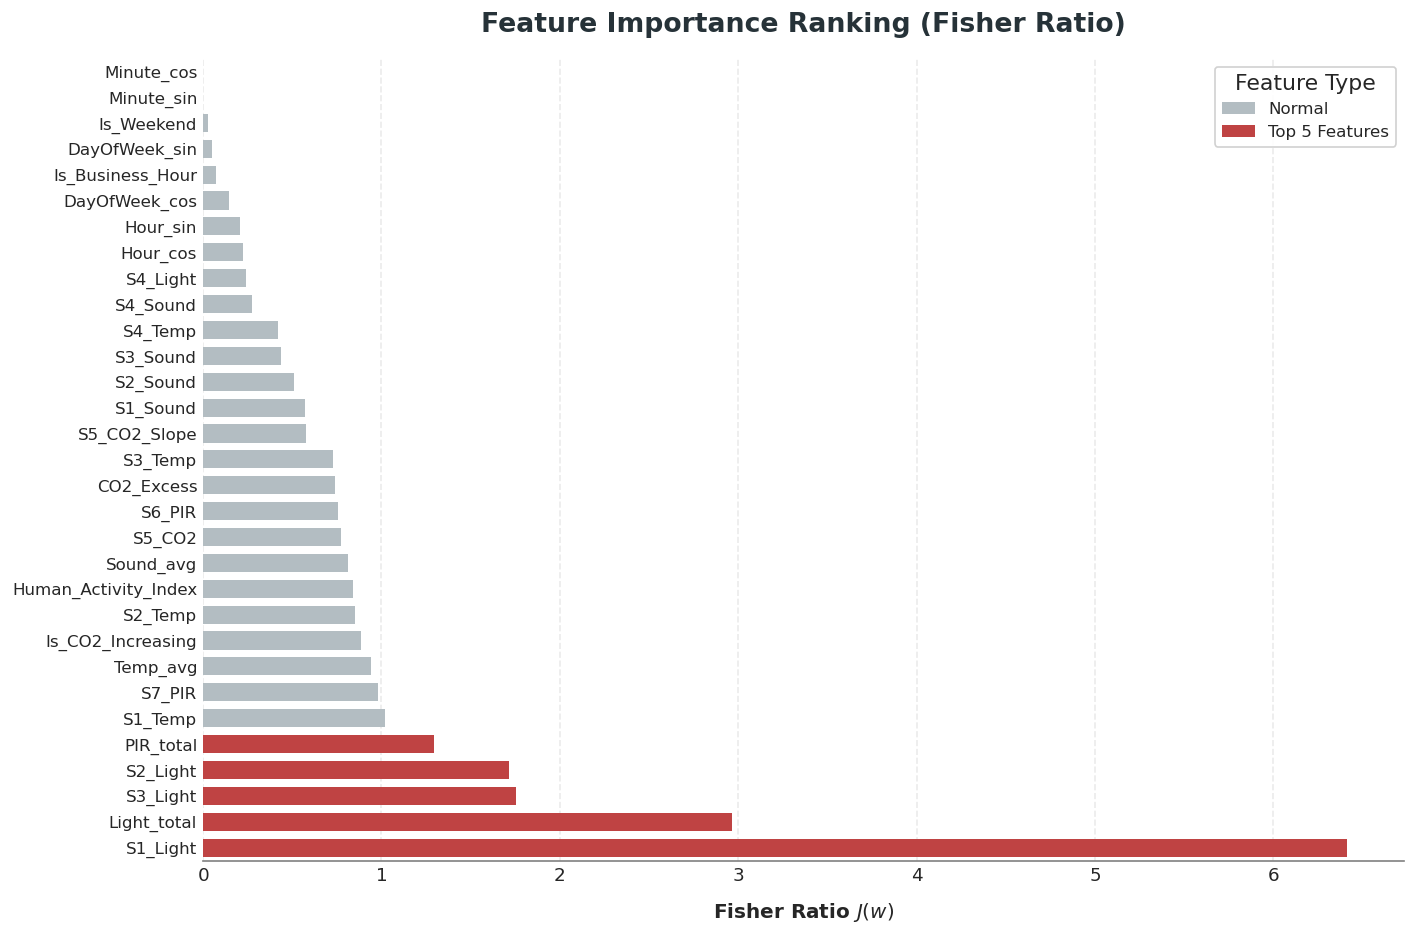

In [ ]:
plot_fisher_ratio_ranking(fisher_df, top_k=5)

Nhìn vào biểu đồ phân bổ tỷ số Fisher, chúng ta có thể rút ra một vài nhận xét:

* Đặc trưng `S1_Light` nắm giữ tỷ số Fisher cao áp đảo ($J(w) \approx 6.41$), bỏ xa tất cả các cảm biến còn lại. Tiếp sau đó là `Light_total`, `S3_Light` và `S2_Light`. Điều này hoàn toàn hợp lý về mặt vật lý học: Trạng thái bật/tắt điện trong phòng là tín hiệu rõ ràng và trực tiếp nhất để suy diễn sự tồn tại của con người (người vào phòng sẽ bật đèn).
* `PIR_total` đứng ở vị trí top 5. Cảm biến hồng ngoại nhận diện biến thiên nhiệt độ (chuyển động của cơ thể), tuy quan trọng nhưng mức độ ổn định không bằng ánh sáng (do con người có thể ngồi im trong phòng).
* Các đặc trưng tuần hoàn liên quan đến chu kỳ phút (`Minute_sin`, `Minute_cos`) đứng bét bảng với Tỷ số Fisher tiệm cận 0. Điều này cho thấy số phút lẻ trong giờ hoàn toàn không mang thông tin phân biệt (người có thể vào phòng ở phút thứ 1 hay thứ 59 đều không tạo ra quy luật rõ ràng).

### **4.3. Dimensionality Reduction & Decision Boundary Visualization**

**Mục tiêu:** LDA không chỉ là một thuật toán phân lớp mà còn là một kỹ thuật giảm chiều dữ liệu có giám sát cực kỳ xuất sắc. Nó sử dụng các vector riêng để chiếu không gian gốc $D$ chiều xuống một không gian con (Fisher space) có số chiều tối đa là $K-1$, sao cho sự phân tách giữa các lớp là lớn nhất.

Trong bài toán này ($K=4$), chúng ta sẽ chiếu không gian gốc xuống 2 chiều (LD1 và LD2). 
*Lưu ý:* QDA không có khả năng giảm chiều dữ liệu vì nó không chia sẻ chung ma trận hiệp phương sai. Tuy nhiên, để so sánh hình dáng ranh giới quyết định, chúng ta sẽ "mượn" không gian 2D do LDA tạo ra, sau đó huấn luyện cả mô hình LDA và QDA trên không gian 2D này để đối chiếu trực tiếp sự khác biệt giữa *đường biên tuyến tính* và *đường biên bậc hai*.

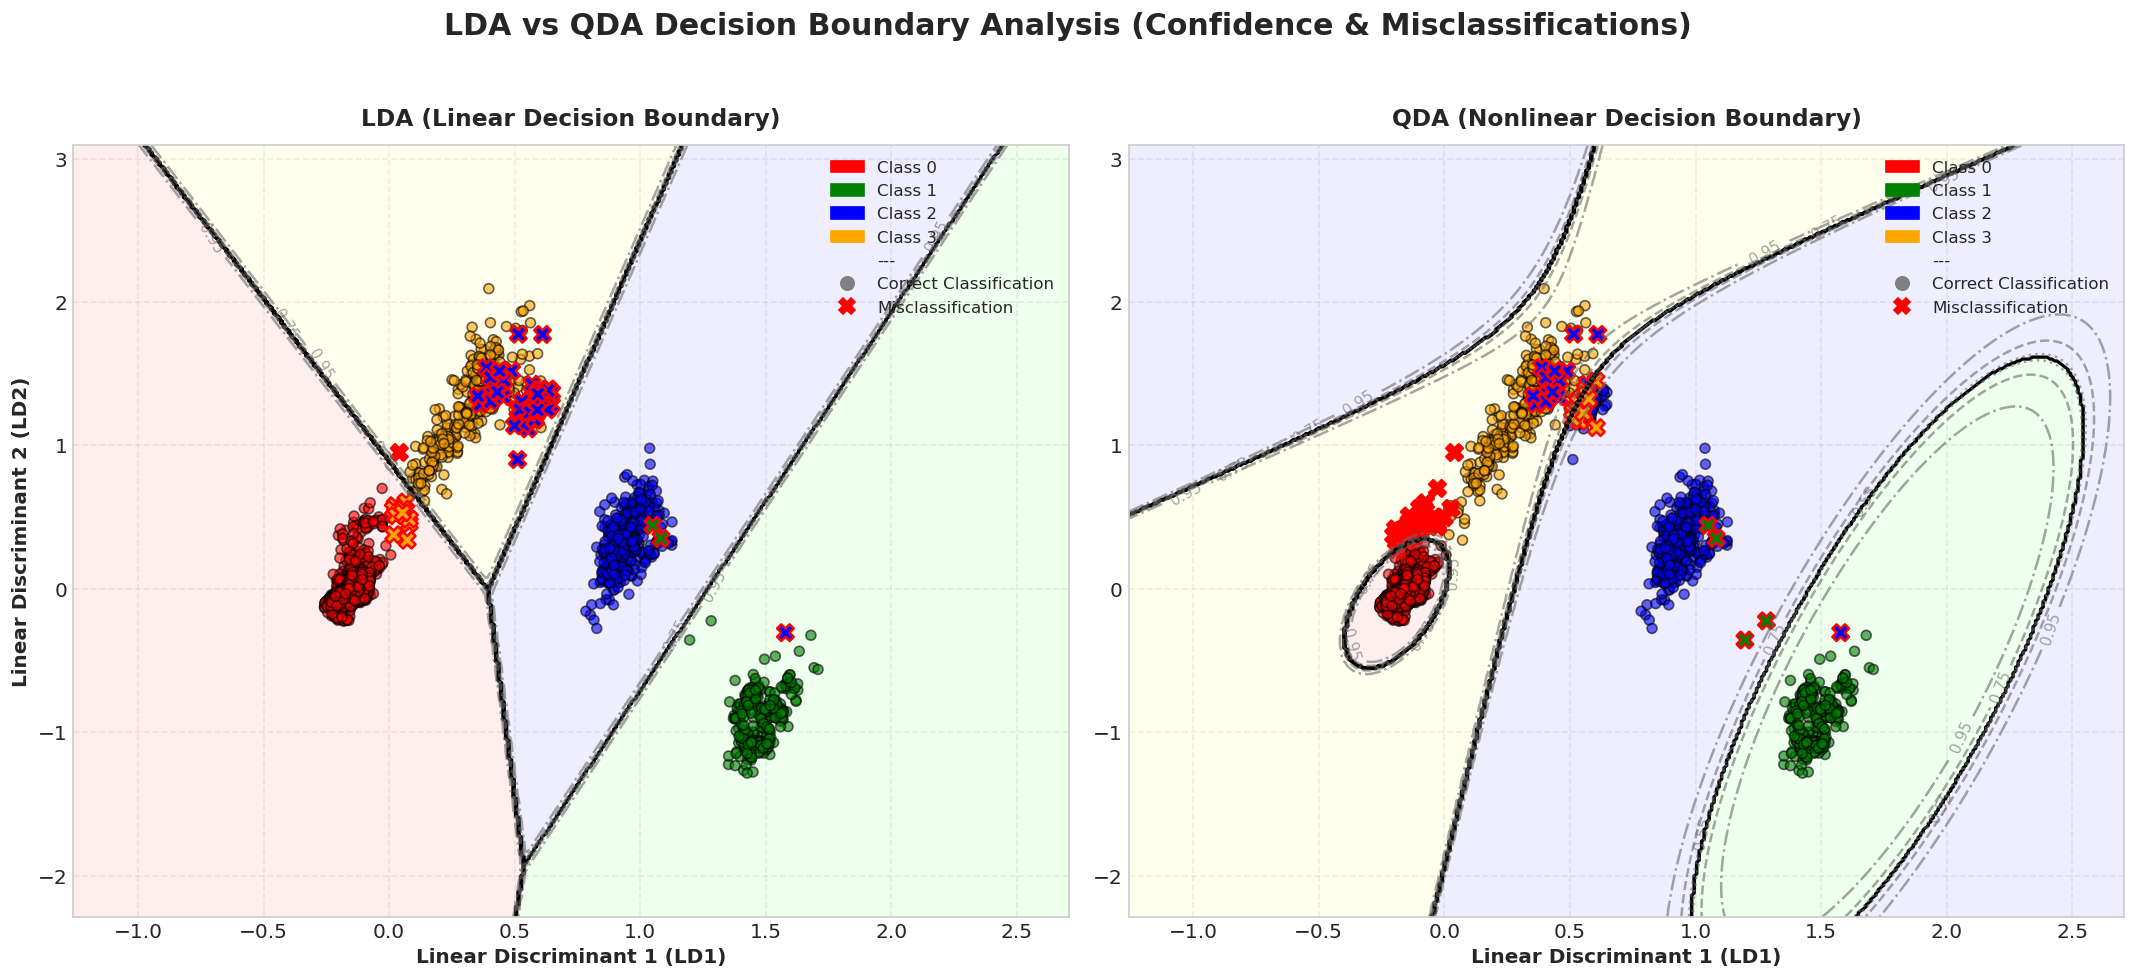

In [ ]:
plot_lda_qda_decision_analysis(
    lda_model=lda_model, 
    qda_model=qda_model, 
    X=X_train_scaled,
    y=y_train)

### **4.4. Analysis and Discussion: The Trade-off Between LDA and QDA**

**1. Về độ phức tạp tham số**
* **LDA:** Chỉ cần ước lượng một ma trận hiệp phương sai chung $\hat{\Sigma}$ cho toàn bộ $K$ lớp, do đó số lượng tham số giới hạn ở mức $\frac{D(D+1)}{2}$.
* **QDA:** Yêu cầu ước lượng $K$ ma trận hiệp phương sai $\tilde{\Sigma}_k$ riêng biệt, đẩy rủi ro tính toán và số lượng tham số lên gấp $K$ lần: $K \times \frac{D(D+1)}{2}$.

**2. Khi nào LDA vượt trội? (Mẫu ít, số chiều cao)**

LDA tỏa sáng trong các bài toán cao chiều nơi dữ liệu thưa thớt, hay còn gọi là *Lời nguyền đa chiều (Curse of Dimensionality)*.
* Khi thiếu hụt dữ liệu huấn luyện, việc QDA cố gắng học các ma trận $\tilde{\Sigma}_k$ riêng biệt sẽ dẫn đến phương sai ước lượng cực cao. Hệ quả tất yếu là ma trận dễ bị suy biến và mô hình rơi vào trạng thái *overfitting* trầm trọng.
* Trong bối cảnh này, giả định "dùng chung hiệp phương sai" của LDA hoạt động như một cơ chế *regularization tự nhiên*. Nó kiểm soát độ phức tạp, giúp các ước lượng ổn định hơn và mang lại khả năng tổng quát hóa tốt hơn trên tập Test.

**3. Khi nào QDA chiếm ưu thế? (Mẫu dồi dào, cấu trúc phi tuyến)**

QDA phát huy tối đa sức mạnh khi có nguồn dữ liệu huấn luyện dồi dào ($N$ rất lớn) và giả định phân chia tuyến tính bị vi phạm.
* Nếu các lớp dữ liệu có định hướng phân tán hình học khác biệt rõ rệt (phương sai lệch nhau), ranh giới siêu phẳng của LDA sẽ trở nên quá cứng nhắc, dẫn đến sai số hệ thống (*underfitting*).
* Khi $N$ đủ lớn để "lấp đầy" các không gian tham số một cách chính xác, sự linh hoạt của QDA cho phép nó vạch ra các đường biên bậc hai (Parabola, Ellipse) uốn lượn ôm sát theo đúng cấu trúc phi tuyến phức tạp của dữ liệu.

## **5. Perceptron**

Thuật toán Perceptron nguyên bản hoạt động theo cơ chế sửa lỗi trực tiếp: thuật toán sẽ cập nhật trọng số mỗi khi phát hiện một mẫu dữ liệu bị đoán sai. Tuy nhiên, bản chất của nó là một bộ phân lớp nhị phân (Binary Classifier) và chỉ cho ra kết quả dự đoán cứng (0 hoặc 1) chứ không hề tính toán xác suất. 

Do bài toán hiện tại yêu cầu phân loại tới 4 lớp (0, 1, 2, 3 người), nhóm đã áp dụng chiến lược **One-vs-One (OvO)**. Cụ thể, mô hình sẽ tạo ra các cặp đấu tay đôi giữa các lớp (tổng cộng có 6 cặp đấu), sau đó dùng cơ chế bầu chọn đa số (Majority Voting) để đưa ra dự đoán cuối cùng. Thực nghiệm dưới đây sẽ huấn luyện Perceptron và quan sát quá trình hội tụ của từng cặp phân lớp.

Training Multiclass Perceptron using One-vs-One (OvO) strategy...
Training completed.

Perceptron (OvO) Test Accuracy: 99.61%



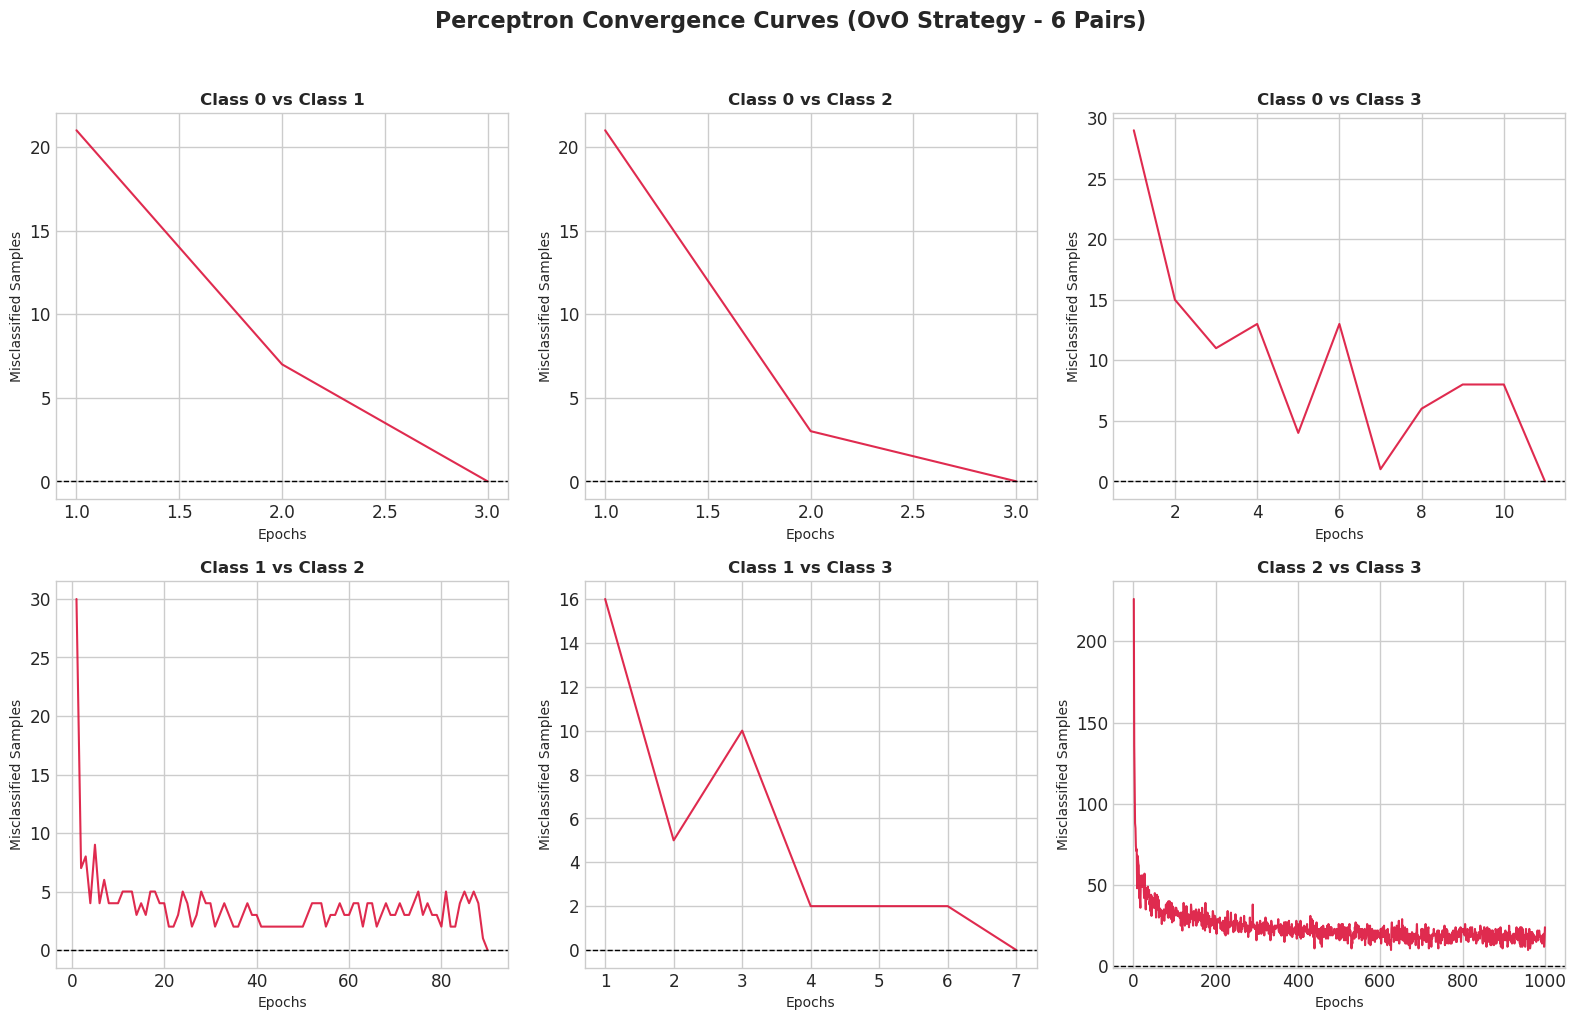

In [ ]:
# Define hyperparameters explicitly
learning_rate = 0.01
max_epochs = 1000

print("Training Multiclass Perceptron using One-vs-One (OvO) strategy...")

# Initialize the OneVsOne wrapper with the custom Perceptron model
# Perceptron is a hard classifier (no predict_proba), so OvO is required
perceptron_ovo = OneVsOneClassifier(
    estimator_cls=Perceptron, 
    learning_rate=learning_rate, 
    max_iter=max_epochs
)

# Train the model on the training set
perceptron_ovo.fit(X_train_scaled, y_train)
print("Training completed.\n")

# Evaluate basic accuracy on the test set
y_pred_test_perc = perceptron_ovo.predict(X_test_scaled)
test_acc_perc = accuracy_score(y_test, y_pred_test_perc)
print(f"Perceptron (OvO) Test Accuracy: {test_acc_perc * 100:.2f}%\n")

# Plot the convergence curve for each binary classifier using subplots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

# Loop through each model to plot their specific error history on a separate subplot
for idx, estimator in enumerate(perceptron_ovo.estimators_):
    errors = estimator.errors_history
    c1, c2 = perceptron_ovo.class_pairs_[idx]
    
    axes[idx].plot(range(1, len(errors) + 1), errors, color='crimson', linewidth=1.5, alpha=0.9)
    axes[idx].set_title(f'Class {c1} vs Class {c2}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Epochs', fontsize=10)
    axes[idx].set_ylabel('Misclassified Samples', fontsize=10)
    axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=1)

plt.suptitle('Perceptron Convergence Curves (OvO Strategy - 6 Pairs)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Nhận xét và phân tích kết quả mô hình Perceptron (OvO):**

Dựa vào đồ thị hội tụ của 6 cặp phân lớp (One-vs-One) trên bộ dữ liệu mới, ta quan sát thấy cục diện rất rõ ràng và thu được những kết luận thú vị về không gian đặc trưng của các cảm biến:

1. **Sự phân tách tuyến tính hoàn hảo (5/6 cặp hội tụ):**
Trái với lo ngại ban đầu, bộ dữ liệu hiện tại cho thấy sự phân tách cực kỳ tốt. Có tới 5 trên 6 cặp đấu (0 vs 1, 0 vs 2, 0 vs 3, 1 vs 2 và 1 vs 3) đều có đường loss đâm thẳng xuống và chạm mốc 0 lỗi. Đặc biệt, các cặp liên quan đến lớp 0 (phòng trống) hội tụ cực kỳ nhanh chỉ sau chưa tới 10 vòng lặp (epoch). Điều này chứng minh rằng các tín hiệu từ cảm biến (như CO2, ánh sáng, nhiệt độ) đã phản ánh rất nhạy bén và tách biệt sự khác nhau giữa phòng không có người, 1 người và 2 người.

2. **Vùng dữ liệu chồng lấn duy nhất (Class 2 vs Class 3):**
Cặp đấu duy nhất thất bại trong việc tìm mặt phẳng phân cách là cặp đếm số người tiệm cận: 2 người và 3 người. Ở đồ thị này, đường lỗi không thể tiến về 0 mà liên tục dao động giật cục (hiện tượng răng cưa) và chạy cạn kiệt giới hạn `max_iter = 1000` vòng lặp. Sự thật thực nghiệm này chỉ ra rằng, lượng nhiệt hoặc CO2 tỏa ra giữa 2 người và 3 người khá tương đồng và hòa lẫn vào nhau (non-linearly separable). Thuật toán Perceptron cứng nhắc cứ cố bẻ ranh giới để đúng với mẫu 2 người thì lại bị lẹm sang điểm dữ liệu của mẫu 3 người, dẫn đến giằng co vô tận.

3. **Lý giải con số Test Accuracy cao đột biến (99.61%):**
Dù bị kẹt ở cặp 2 vs 3, nhưng nhờ chiến lược chia để trị của One-vs-One kết hợp với cơ chế bầu chọn đa số (Majority Voting), Perceptron đã xử lý hoàn hảo gần như toàn bộ các trường hợp còn lại. Hơn nữa, những mẫu bị nhầm lẫn giữa 2 và 3 người chiếm tỷ trọng quá nhỏ so với tổng thể tập test, do đó chúng không đủ sức kéo điểm số xuống, giúp mô hình cán đích với độ chính xác tổng thể cực kỳ ấn tượng là 99.61%.

## **6.Logistic Regression: Regularization (L1/L2), Class-Weighted Loss and Stratified K-Fold CV**

Trong phần này, nhóm sử dụng lại lõi thuật toán `Logistic Regression` tự cài đặt với hai cơ chế tối ưu quan trọng:
* **Hàm mất mát có trọng số (Class-Weighted Loss):** Để xử lý việc tập dữ liệu bị mất cân bằng trầm trọng (thời gian phòng trống chiếm đa số), trọng số cân bằng được gán vào hàm mất mát nhằm ép mô hình phải chú ý hơn vào các lớp thiểu số (phòng có 1, 2, 3 người).
* **Điều chuẩn L1 (Lasso) / L2 (Ridge):** Giới hạn độ lớn của trọng số để tránh việc mô hình bị quá khớp (overfitting) với các đặc trưng nhiễu.

Bên cạnh đó, vì Logistic Regression có khả năng dự đoán xác suất, nhóm áp dụng chiến lược **One-vs-Rest (OvR)** (Một chống lại phần còn lại) để giải quyết bài toán 4 class. Việc chọn ra hàm phạt và hệ số $\lambda$ tối ưu nhất được thực hiện khách quan thông qua **Stratified 5-Fold Cross Validation**.

In [ ]:
# Define the hyperparameter grid for Logistic Regression
penalties = ['l1', 'l2']
lambda_values = [0.001, 0.01, 0.1, 1.0, 10.0]
k_splits = 5

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=k_splits, shuffle=True, random_state=42)

best_cv_acc = 0
best_params = {'penalty': None, 'lambda_reg': None}
cv_results_log = []

print(f"--- Starting Stratified {k_splits}-Fold CV for Multiclass Logistic Regression ---")
print("-" * 75)
print(f"{'Penalty':<10} | {'Lambda':<10} | {'Mean CV Accuracy (%)':<25} | {'Std Dev (%)':<15}")
print("-" * 75)

# Grid Search loop
for penalty in penalties:
    for lam in lambda_values:
        fold_accuracies = []
        
        for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_scaled, y_train)):
            X_cv_train, X_cv_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
            y_cv_train, y_cv_val = y_train[train_idx], y_train[val_idx]
            
            # Initialize the wrapper with Custom Logistic Regression inside
            # Logistic Regression supports probabilities, so OvR is used
            lr_cv_model = OneVsRestClassifier(
                estimator_cls=LogisticRegression,
                learning_rate=0.1, 
                max_iter=500, 
                penalty=penalty, 
                lambda_reg=lam, 
                class_weight='balanced'
            )
            
            lr_cv_model.fit(X_cv_train, y_cv_train)
            
            y_pred_val = lr_cv_model.predict(X_cv_val)
            acc = accuracy_score(y_cv_val, y_pred_val)
            fold_accuracies.append(acc)
            
        mean_acc = np.mean(fold_accuracies)
        std_acc = np.std(fold_accuracies)
        
        cv_results_log.append({
            'Penalty': penalty.upper(), 
            'Lambda': lam, 
            'Mean_CV_Accuracy': mean_acc,
            'Std_Dev': std_acc
        })
        
        print(f"{penalty.upper():<10} | {lam:<10} | {mean_acc*100:<25.2f} | {std_acc*100:<15.2f}")
        
        if mean_acc > best_cv_acc:
            best_cv_acc = mean_acc
            best_params = {'penalty': penalty, 'lambda_reg': lam}

print("-" * 75)
print(f">>> BEST PARAMS FOUND: Penalty = {best_params['penalty'].upper()}, Lambda = {best_params['lambda_reg']}")
print(f">>> BEST CV ACCURACY:  {best_cv_acc*100:.2f}%")

--- Starting Stratified 5-Fold CV for Multiclass Logistic Regression ---
---------------------------------------------------------------------------
Penalty    | Lambda     | Mean CV Accuracy (%)      | Std Dev (%)    
---------------------------------------------------------------------------
L1         | 0.001      | 96.28                     | 0.39           
L1         | 0.01       | 95.92                     | 0.37           
L1         | 0.1        | 92.74                     | 0.23           
L1         | 1.0        | 84.37                     | 2.86           
L1         | 10.0       | 59.76                     | 15.57          
L2         | 0.001      | 96.30                     | 0.43           
L2         | 0.01       | 96.17                     | 0.51           
L2         | 0.1        | 94.36                     | 0.82           
L2         | 1.0        | 91.10                     | 0.66           
L2         | 10.0       | 91.53                     | 0.62           
-----

**Nhận xét quá trình dò tìm siêu tham số (Grid Search CV):**

Từ bảng kết quả Stratified 5-Fold CV, ta có thể rút ra những đánh giá quan trọng về hành vi của hai loại điều chuẩn (Regularization) trên bộ dữ liệu này:

1. **Bộ tham số vô địch:** Cấu hình mang lại độ chính xác trung bình cao nhất (96.30%) là **Penalty = L2** với hệ số phạt rất nhỏ **Lambda = 0.001**. Cấu hình L1 tương ứng bám sát nút với 96.28%. Với mức phạt $\lambda$ thấp, cả hai mô hình đều chỉ đang "tỉa" nhẹ các nhiễu cục bộ mà không làm mất đi các đặc trưng cốt lõi của cảm biến.

2. **Sự sụp đổ của L1 khi phạt nặng (Underfitting):** Quan sát sự thay đổi khi đẩy $\lambda$ lên mức tối đa ($10.0$), ta thấy một sự phân hóa toán học cực kỳ rõ rệt:
   * Mô hình L2 giảm nhẹ độ chính xác xuống 91.53% (vẫn giữ được tính khái quát). 
   * Tuy nhiên, mô hình L1 sụp đổ hoàn toàn, Accuracy cắm đầu xuống chỉ còn 59.76% đi kèm với độ lệch chuẩn cực lớn (15.57%). 
   Nguyên nhân cốt lõi là do bản chất tạo tính thưa (Sparsity) của L1. Khi mức thuế phạt quá cao, L1 thẳng tay ép hàng loạt vector trọng số về chính xác mốc $0$, khiến mô hình bị "mù" đặc trưng và mất hoàn toàn khả năng nhận diện các quy luật cơ bản của lượng người trong phòng.

3. **Chốt lại:** Đối với không gian đặc trưng của bộ dữ liệu `Room_Occupancy`, việc giữ lại và co rút nhẹ đồng đều các trọng số (L2) tỏ ra ổn định hơn so với việc thẳng tay triệt tiêu (L1). Nhóm quyết định sử dụng cấu hình (L2, Lambda = 0.001) cho mô hình chốt hạ cuối cùng.

## **7. Evaluating the Optimized Logistic Regression Model**

Sau khi xác định được bộ tham số tối ưu (`Penalty = L2`, `Lambda = 0.001`), nhóm tiến hành:
1. Huấn luyện lại mô hình trên toàn bộ tập Train.
2. Vẽ đồ thị Learning Curve qua hàm mất mát (Cross-Entropy Loss) để quan sát quá trình hội tụ.
3. Đánh giá hiệu năng trên tập Test bằng Ma trận nhầm lẫn (Confusion Matrix) và Báo cáo phân lớp (Classification Report). Quá trình này sẽ cho thấy sức mạnh của việc tích hợp `class_weight='balanced'` trong việc nhận diện lớp thiểu số.

Training the final Multiclass Logistic Regression model with Penalty=L2, Lambda=0.001...
Training completed successfully.

-------------------------------------------------------
Final Model Test Accuracy: 96.99%
-------------------------------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1646
           1       1.00      0.99      0.99        92
           2       0.75      0.93      0.83       149
           3       0.86      0.69      0.76       139

    accuracy                           0.97      2026
   macro avg       0.90      0.90      0.90      2026
weighted avg       0.97      0.97      0.97      2026



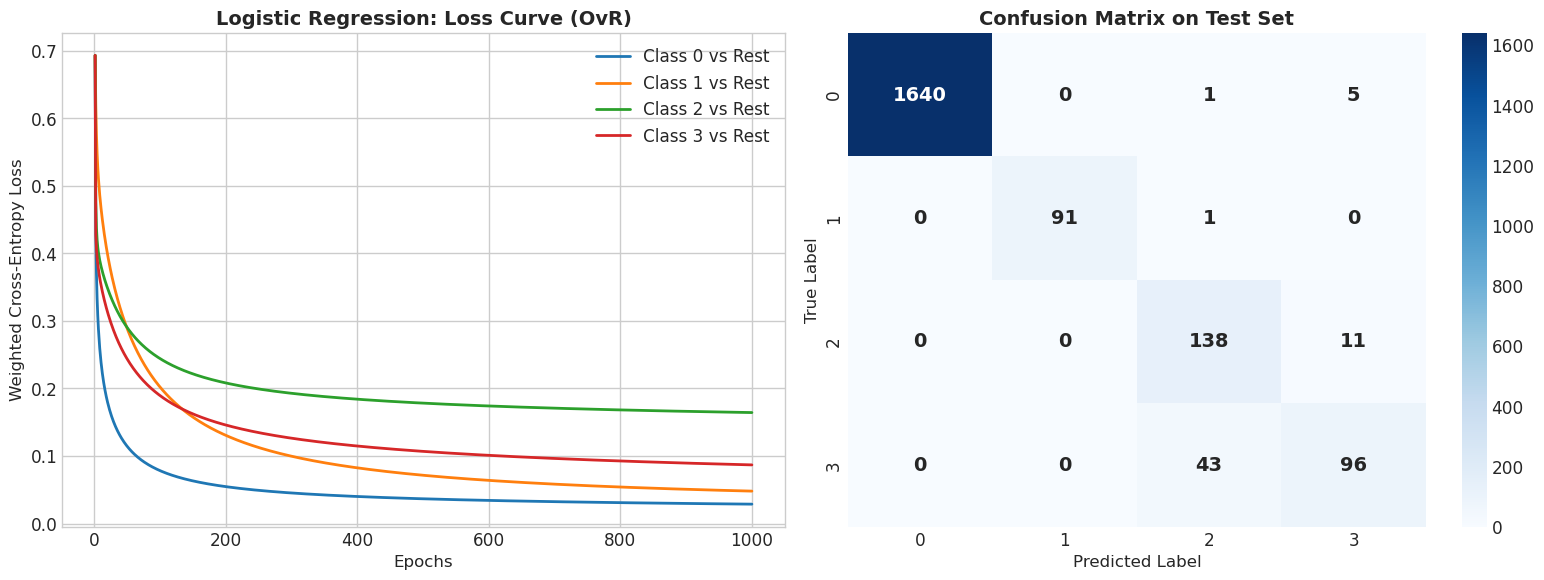

In [ ]:
# Extract the best hyperparameters
best_penalty = best_params['penalty']
best_lambda = best_params['lambda_reg']

print(f"Training the final Multiclass Logistic Regression model with Penalty={best_penalty.upper()}, Lambda={best_lambda}...")

# Initialize final model using One-vs-Rest strategy
best_lr_model = OneVsRestClassifier(
    estimator_cls=LogisticRegression,
    learning_rate=0.1, 
    max_iter=1000, 
    penalty=best_penalty, 
    lambda_reg=best_lambda, 
    class_weight='balanced'
)

# Train on the full training set
best_lr_model.fit(X_train_scaled, y_train)
print("Training completed successfully.\n")

# Evaluate on the test set
y_pred_test_lr = best_lr_model.predict(X_test_scaled)
test_acc_lr = accuracy_score(y_test, y_pred_test_lr)

print("-" * 55)
print(f"Final Model Test Accuracy: {test_acc_lr*100:.2f}%")
print("-" * 55)
print("Classification Report:")
# zero_division=0 prevents warnings if a class is completely missed
print(classification_report(y_test, y_pred_test_lr, zero_division=0))

# Visualizations: Loss Curve and Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot the Loss Curve for each of the 4 internal models
for idx, estimator in enumerate(best_lr_model.estimators_):
    axes[0].plot(range(1, len(estimator.loss_history) + 1), estimator.loss_history, 
                 linewidth=2, label=f'Class {best_lr_model.classes_[idx]} vs Rest')

axes[0].set_title('Logistic Regression: Loss Curve (OvR)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epochs', fontsize=12)
axes[0].set_ylabel('Weighted Cross-Entropy Loss', fontsize=12)
axes[0].legend()

# Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred_test_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], 
            xticklabels=best_lr_model.classes_, 
            yticklabels=best_lr_model.classes_,
            annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title('Confusion Matrix on Test Set', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted Label', fontsize=12)
axes[1].set_ylabel('True Label', fontsize=12)

plt.tight_layout()
plt.show()

**Đánh giá thực tế mô hình Logistic Regression (OvR) trên tập Test:**

Việc chuyển đổi từ phân lớp cứng (Perceptron) sang phân lớp xác suất có điều chuẩn (Logistic Regression) kết hợp với trọng số cân bằng lớp (class-weight) đã mang lại một bước nhảy vọt về mặt chất lượng:

1. **Hiệu năng tổng thể ấn tượng:** Mô hình cán đích với Test Accuracy đạt 96.99%, Macro F1-score đạt 0.90. Đây là những con số minh chứng cho việc lõi thuật toán tối ưu Gradient Descent cùng chiến lược One-vs-Rest (OvR) đã được nhóm cài đặt hoàn toàn chuẩn xác.

2. **Khắc phục thành công sự mất cân bằng dữ liệu (Class Imbalance):** Dù Lớp 0 (phòng trống) áp đảo tập Test với 1646/2026 mẫu, mô hình không hề bị rơi vào bẫy "đoán mò theo số đông". Nhờ áp dụng công thức Class-Weighted Loss (phạt nặng khi đoán sai lớp thiểu số), các lớp 1 và 2 đã được mô hình "tôn trọng" với mức Recall cực cao (lần lượt là 0.99 và 0.93). Điều này cho thấy ranh giới tuyến tính đã chủ động bẻ cong để ôm trọn lấy các điểm dữ liệu hiếm gặp.

3. **Góc khuất duy nhất: Điểm yếu chí mạng tại Lớp 2 vs Lớp 3:**
Sự liên kết thực nghiệm giữa Perceptron và Logistic Regression được thể hiện rất rõ ở Class 3 (Phòng có 3 người). Trong Classification Report, điểm Recall của Class 3 rớt xuống thấp nhất (chỉ 0.69). Đồng thời, Precision của Class 2 chỉ đạt 0.75. 
Bức tranh toán học đằng sau con số này là: Mô hình đang bị nhầm lẫn trầm trọng giữa 2 người và 3 người (nó liên tục gán nhầm các mẫu của Lớp 3 sang Lớp 2). Hiện tượng này hoàn toàn khớp với việc đường Loss của cặp OvO (2 vs 3) của Perceptron không thể hội tụ. 

$\rightarrow$ **Kết luận chung:** Logistic Regression đã làm rất tốt nhiệm vụ của một mô hình tuyến tính: khử nhiễu (L2 Regularization) và ép mô hình học các lớp thiểu số (Class-weight). Tuy nhiên, vì bản chất vẫn là dùng siêu phẳng tuyến tính, nó bất lực trước việc bóc tách những vùng dữ liệu giao thoa quá chặt chẽ (như ranh giới cảm biến nhiệt/CO2 giữa 2 và 3 người). Để nâng cấp, bài toán đòi hỏi phải sử dụng các không gian biến đổi hạt nhân (Kernel Methods) hoặc các mô hình phân nhánh phi tuyến (Tree-based models).